In [4]:
# ============================================
# PredictIQ — Modèle Random Forest RUL
# ============================================
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries importées")

✅ Libraries importées


In [5]:
DATA_PATH = r'C:\Users\pc\Desktop\PredictIQ\Data Set'

col_names = ['unit_id', 'cycle', 'op1', 'op2', 'op3'] + \
            [f's{i}' for i in range(1, 22)]

train = pd.read_csv(os.path.join(DATA_PATH, 'train_FD001.txt'), 
                    sep='\s+', header=None, names=col_names)

# Calcul RUL
max_cycles = train.groupby('unit_id')['cycle'].max().reset_index()
max_cycles.columns = ['unit_id', 'max_cycle']
train = train.merge(max_cycles, on='unit_id')
train['RUL'] = train['max_cycle'] - train['cycle']
train.drop('max_cycle', axis=1, inplace=True)

# Capteurs utiles
useless = ['s1', 's5', 's10', 's16', 's18', 's19']
useful = [s for s in [f's{i}' for i in range(1, 22)] if s not in useless]

X = train[['cycle'] + useful]
y = train['RUL']

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42)

print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
print("✅ Données prêtes")

X_train: (16504, 16) | X_test: (4127, 16)
✅ Données prêtes


In [6]:
rf_model = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)
print("✅ Modèle entraîné !")

✅ Modèle entraîné !


In [7]:
y_pred = rf_model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print("=" * 40)
print(f"  RMSE : {rmse:.2f} cycles")
print(f"  MAE  : {mae:.2f} cycles")
print(f"  R²   : {r2:.4f}")
print("=" * 40)

  RMSE : 35.85 cycles
  MAE  : 25.34 cycles
  R²   : 0.7187


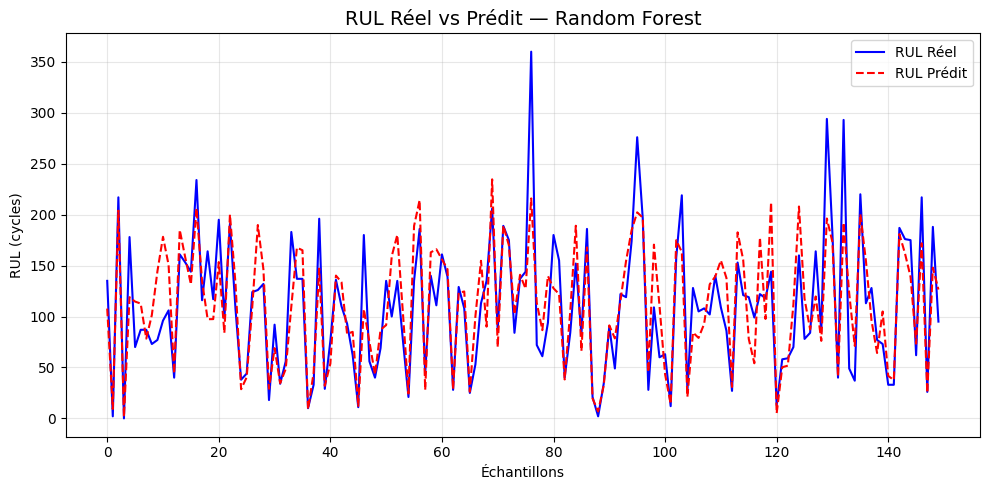

In [8]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values[:150], label='RUL Réel', color='blue', linewidth=1.5)
plt.plot(y_pred[:150], label='RUL Prédit', color='red', linewidth=1.5, linestyle='--')
plt.title('RUL Réel vs Prédit — Random Forest', fontsize=14)
plt.xlabel('Échantillons')
plt.ylabel('RUL (cycles)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../models/prediction_vs_reel.png', dpi=150)
plt.show()

In [9]:
joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(scaler,   '../models/scaler.pkl')
print("✅ Modèle sauvegardé !")

✅ Modèle sauvegardé !
